# Detección de vehículos mediante clustering de datos LIDAR

**Objetivo:** a partir de una nube de puntos capturada por un LIDAR de infraestructura,
detectar cuántos vehículos hay presentes, aplicando:
1. Preprocesado (limpieza de puntos y eliminación del suelo)
2. Clustering con DBSCAN
3. Clustering con K-Means (configurado según el resultado de DBSCAN)

## 1. Librerías utilizadas

- **pandas**: para cargar el CSV como una tabla (`DataFrame`) y poder filtrar,
  seleccionar columnas y hacer estadísticas descriptivas fácilmente.
- **numpy**: la base numérica de Python científico. La usamos para trabajar con
  los puntos como arrays de números (vectores y matrices), mucho más rápido que
  usar listas de Python normales.
- **matplotlib**: para dibujar gráficas (dispersión de puntos, histogramas) y
  poder inspeccionar visualmente la nube de puntos y los resultados.
- **open3d**: librería especializada en nubes de puntos 3D. La usamos para
  detectar automáticamente el plano del suelo (algoritmo RANSAC), algo tedioso
  de programar a mano desde cero.
- **scikit-learn**: aquí están implementados los algoritmos de clustering que
  pide la práctica, `DBSCAN` y `KMeans`, ya optimizados y listos para usar.
- **scipy**: aquí esta implementada la estructura de búsqueda espacial `KDTree` que
  utilizaremos para la eliminación de puntos no necesarios.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
from sklearn.cluster import DBSCAN, KMeans
from scipy.spatial import cKDTree

## 2. Carga y exploración de los datos

Antes de aplicar cualquier algoritmo, es importante entender qué contienen los datos:
cuántos puntos hay, qué rango de valores tienen, y si hay puntos "vacíos" o inválidos
que haya que descartar.

In [15]:
df = pd.read_csv('data/carretera.csv')
df.head()

,x,y,z,intensity,t,reflectivity,ring,ambient,range
0,-0.000000,0.000000,0.000000,0.0,586440720,0,0,0,0
1,-0.000000,0.000000,0.000000,12.0,0,0,0,1561,0
2,-0.000000,0.000000,0.000000,10.0,44800,0,0,999,0
3,-13.051449,2.743896,13.195881,14.0,95720,3,0,680,18743
4,-12.942629,2.804015,13.103083,18.0,142080,4,0,737,18611


In [16]:
print("Número de puntos:", len(df))
print("Columnas:", list(df.columns))
df.info()

Número de puntos: 131072
Columnas: ['x', 'y', 'z', 'intensity', 't', 'reflectivity', 'ring', 'ambient', 'range']
<class 'pandas.DataFrame'>
RangeIndex: 131072 entries, 0 to 131071
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   x             131072 non-null  float64
 1   y             131072 non-null  float64
 2   z             131072 non-null  float64
 3   intensity     131072 non-null  float64
 4   t             131072 non-null  int64  
 5   reflectivity  131072 non-null  int64  
 6   ring          131072 non-null  int64  
 7   ambient       131072 non-null  int64  
 8   range         131072 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 9.0 MB


### 2.1 Detección de puntos inválidos

El sensor genera una fila por cada disparo láser, incluso cuando no recibe ningún
retorno (por ejemplo, si el láser apunta al cielo o muy lejos). Estos "disparos vacíos"
se identifican porque su columna `range` (distancia al punto) vale 0.

Antes de limpiar, comprobamos cuántos puntos son inválidos.

In [17]:
puntos_invalidos = (df['range'] == 0).sum()
puntos_validos = (df['range'] > 0).sum()

print(f"Puntos inválidos (range=0): {puntos_invalidos} ({puntos_invalidos/len(df)*100:.1f}%)")
print(f"Puntos válidos (range>0): {puntos_validos} ({puntos_validos/len(df)*100:.1f}%)")

Puntos inválidos (range=0): 73755 (56.3%)
Puntos válidos (range>0): 57317 (43.7%)


### 2.2 Limpieza: nos quedamos solo con los puntos válidos

Definimos una función para filtrar el DataFrame y descartar los disparos sin retorno (`range == 0`).
También descartamos, por precaución, puntos con un `range` absurdamente grande,
que podrían ser reflejos erróneos o ruido del sensor.

In [18]:
def limpiar_puntos(df):
    """
    Limpia los puntos del DataFrame según el rango.
    """
    df_limpio = df[(df['range'] > 0) & (df['range'] < 30000)].copy()
    print(f"Puntos antes de limpiar: {len(df)}")
    print(f"Puntos después de limpiar: {len(df_limpio)}")
    return df_limpio

df_limpio = limpiar_puntos(df)

Puntos antes de limpiar: 131072
Puntos después de limpiar: 56848


## 3. Primera visualización de la nube de puntos

Antes de aplicar ningún algoritmo, visualizamos los puntos para entender la escena:
¿cómo está orientado el sensor? ¿dónde está el suelo? ¿se distingue algo a simple vista?

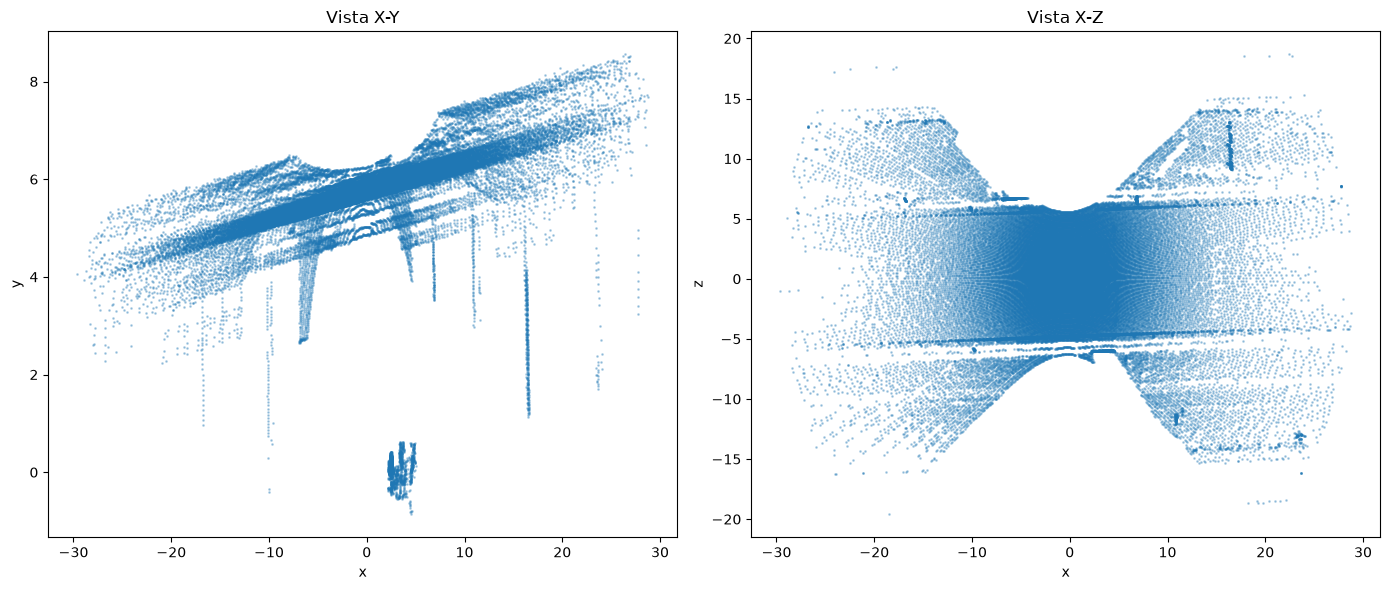

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(df_limpio['x'], df_limpio['y'], s=1, alpha=0.3)
axes[0].set_title('Vista X-Y')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

axes[1].scatter(df_limpio['x'], df_limpio['z'], s=1, alpha=0.3)
axes[1].set_title('Vista X-Z')
axes[1].set_xlabel('x')
axes[1].set_ylabel('z')

plt.tight_layout()
plt.show()

## 4. Eliminación del fondo

Usamos la nube de puntos en la que no tenemos ningún vehiculo, para poder aplicar más adelante una resta de fondo por proximidad espacial mediante un KDTree para descartar todos los puntos de esta cuando analicemos otra nube y asi quedarnos únicamente con los puntos que correspondan a vehículos.

In [20]:
coords_fondo = df_limpio[["x", "y", "z"]].values
tree_fondo = cKDTree(coords_fondo)

Definimos una función para eliminar el fondo de los dataframes en los que aparecen vehículos:
1. Consultamos la distancia mínima de cada punto respecto al fondo.
2. Conservamos únicamente los puntos alejados del fondo por encima del umbral.
3. Mostramos los puntos que tiene finalmente la nube, los puntos decartados y los puntos pertenecientes a los vehículos.

In [21]:
def sustraer_fondo(df_vehiculos, tree_fondo):
    """
    Elimina los puntos de la carretera/fondo calculando la distancia mínima al KDTree.
    Retorna el DataFrame con solo los puntos pertenecientes a objetos/vehículos.
    """
    coords_nube = df_vehiculos[['x', 'y', 'z']].values
    
    distancias, _ = tree_fondo.query(coords_nube, k=1, workers=-1)
    
    df_vehiculos_limpio = df_vehiculos[distancias > 0.25].copy()
    
    print(f"Puntos de la nube: {len(df_vehiculos)}")
    print(f"Puntos de la carretera descartados: {(distancias <= 0.25).sum()}")
    print(f"Puntos pertenecientes a vehículos retenidos: {len(df_vehiculos_limpio)}")
    
    return df_vehiculos_limpio

## 5. Clustering con DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) agrupa puntos
según su densidad: si un punto tiene suficientes vecinos cerca, forma parte de un
cluster; si está aislado, se marca como ruido. A diferencia de K-Means, no necesita
que le digamos de antemano cuántos clusters buscar.

Parámetros clave:
- `eps`: distancia máxima entre dos puntos para considerarlos "vecinos"
- `min_samples`: número mínimo de vecinos que necesita un punto para no ser ruido

### 5.1 Aplicar DBSCAN sobre los puntos "no suelo"

Extraemos las coordenadas tri-dimensionales del DataFrame filtrado (df_limpio) y aplicamos el algoritmo DBSCAN para agrupar las estructuras según su densidad espacial, lo definimos en una función para poder reutilizarlo, los valores de eps y min_samples variaran en función del problema..

In [22]:
def dbscan(df_vehiculos_limpio, eps_val, min_samples_val):
    """
    Aplica el algoritmo DBSCAN para detectar clusters de vehículos.
    Retorna el DataFrame con una nueva columna 'cluster' indicando el cluster asignado a cada punto.
    """
    coords = df_vehiculos_limpio[['x', 'y', 'z']].values

    db = DBSCAN(eps=eps_val, min_samples=min_samples_val).fit(coords)
    labels = db.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = list(labels).count(-1)

    print(f"Número de clusters detectados: {n_clusters}")
    print(f"Puntos clasificados como ruido: {n_ruido}")

    df_vehiculos_limpio['cluster'] = labels
    
    return labels


Los números de clusters detectados deberán coincidir con los vehículos que haya.

### 5.2 Visualización de la nube de puntos clusterizada

In [ ]:
import plotly.graph_objects as go

def plot_clusters(coords, labels):
    # 1. Asegurar formato de coordenadas (N, 3)
    coords = np.asarray(coords, dtype=np.float64)
    if coords.shape[0] == 3 and coords.shape[1] != 3:
        coords = coords.T

    # 2. Configurar colores y grupos
    etiquetas_unicas = sorted(set(labels))
    colores_paleta = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 
                      'pink', 'olive', 'cyan', 'magenta']
    
    trazos = []
    
    # 3. Iterar por cada cluster para crear las capas (trazos) de Plotly
    for etiqueta in etiquetas_unicas:
        # Filtrar puntos correspondientes a la etiqueta actual
        puntos_cluster = coords[labels == etiqueta]
        x, y, z = puntos_cluster[:, 0], puntos_cluster[:, 1], puntos_cluster[:, 2]
        
        if etiqueta == -1:
            nombre = "Ruido"
            color = "lightgray"
        else:
            nombre = f"Cluster {etiqueta}"
            color = colores_paleta[etiqueta % len(colores_paleta)]
            
        # Añadir el grupo de puntos a la lista de trazos
        trazos.append(go.Scatter3d(
            x=x, y=y, z=z,
            mode='markers',
            name=nombre,
            marker=dict(size=2, color=color, opacity=0.8)
        ))

    # 4. Crear la figura y ajustar para evitar deformación
    fig = go.Figure(data=trazos)
    
    fig.update_layout(
        scene=dict(
            aspectmode='data', # ¡Clave para que no pierda la forma!
            xaxis_title='X', yaxis_title='Y', zaxis_title='Z'
        ),
        margin=dict(r=0, l=0, b=0, t=30),
        title="Clusters encontrados",
        legend=dict(itemsizing='constant') # Mantiene los puntos de leyenda visibles
    )
    
    fig.show()

## 6.Resultados de aplicarlo en todos los datasets.

Vamos a implementar las llamadas necesarias para mostrar los resultados de aplicar DBScan en todos los dataset siguiendo siempre el mismo orden:
1. Cargamos el dataset.
2. Eliminamos el fondo y los valores anómalos.
3. Ejecutamos DBScan
4. Visualizamos la nube.

### 6.1 Dataset 1_coche.csv

In [24]:
df = pd.read_csv('data/1_coche.csv')
df_vehiculos_limpio = sustraer_fondo(limpiar_puntos(df), tree_fondo)
coords = df_vehiculos_limpio[['x', 'y', 'z']].values
labels = dbscan(df_vehiculos_limpio, eps_val=0.5, min_samples_val=15)
plot_clusters(coords, labels)


Puntos antes de limpiar: 131072
Puntos después de limpiar: 56568
Puntos de la nube: 56568
Puntos de la carretera descartados: 53019
Puntos pertenecientes a vehículos retenidos: 3549
Número de clusters detectados: 1
Puntos clasificados como ruido: 442


### 6.2 Dataset coche_coche_moto.csv

In [63]:
df = pd.read_csv('data/coche_coche_moto.csv')
df_vehiculos_limpio = sustraer_fondo(limpiar_puntos(df), tree_fondo)
coords = df_vehiculos_limpio[['x', 'y', 'z']].values
labels = dbscan(df_vehiculos_limpio, eps_val=0.7, min_samples_val=10)
plot_clusters(coords, labels)

Puntos antes de limpiar: 131072
Puntos después de limpiar: 56454
Puntos de la nube: 56454
Puntos de la carretera descartados: 51817
Puntos pertenecientes a vehículos retenidos: 4637
Número de clusters detectados: 3
Puntos clasificados como ruido: 462


### 6.3 Dataset coche_coche.csv

In [26]:
df = pd.read_csv('data/coche_coche.csv')
df_vehiculos_limpio = sustraer_fondo(limpiar_puntos(df), tree_fondo)
coords = df_vehiculos_limpio[['x', 'y', 'z']].values
labels = dbscan(df_vehiculos_limpio, eps_val=0.5, min_samples_val=20)
plot_clusters(coords, labels)


Puntos antes de limpiar: 131072
Puntos después de limpiar: 55497
Puntos de la nube: 55497
Puntos de la carretera descartados: 52942
Puntos pertenecientes a vehículos retenidos: 2555
Número de clusters detectados: 2
Puntos clasificados como ruido: 507


### 6.4 Dataset pointcloud.csv.

In [69]:
df = pd.read_csv('data/pointcloud_1686138334837467970.csv')
df_vehiculos_limpio = sustraer_fondo(limpiar_puntos(df), tree_fondo)
coords = df_vehiculos_limpio[['x', 'y', 'z']].values
labels = dbscan(df_vehiculos_limpio, eps_val=0.5, min_samples_val=10)
plot_clusters(coords, labels)

Puntos antes de limpiar: 131072
Puntos después de limpiar: 56705
Puntos de la nube: 56705
Puntos de la carretera descartados: 56053
Puntos pertenecientes a vehículos retenidos: 652
Número de clusters detectados: 1
Puntos clasificados como ruido: 402


## 7. Clusterización con K-Means.

In [28]:
from sklearn.cluster import KMeans

def kmeans(puntos, n_clusters_val, random_state_val=42):
    """
    Aplica el algoritmo K-Means a una nube de puntos.
    
    Parámetros:
    - puntos: array-like de forma (n_samples, n_features), coordenadas de los puntos (nube limpia).
    - n_clusters_val: int, el número de clusters (k) a formar.
    - random_state_val: int, semilla para la inicialización aleatoria (garantiza reproducibilidad).
    
    Retorna:
    - labels: array de numpy con las etiquetas asignadas a cada punto (de 0 a n_clusters_val - 1).
    """
    # 1. Inicializar el modelo K-Means con los parámetros dados
    # n_init='auto' suprime warnings en versiones recientes de scikit-learn
    modelo_kmeans = KMeans(n_clusters=n_clusters_val, random_state=random_state_val, n_init='auto')
    
    # 2. Ajustar el modelo a los puntos y obtener las etiquetas
    labels = modelo_kmeans.fit_predict(puntos)
    
    return labels

### 7.1 Dataset 1_coche.csv

In [40]:
df = pd.read_csv('data/1_coche.csv')
df_vehiculos_limpio = sustraer_fondo(limpiar_puntos(df), tree_fondo)
coords = df_vehiculos_limpio[['x', 'y', 'z']].values
labels = kmeans(coords, n_clusters_val=3, random_state_val=42)
plot_clusters(coords, labels)

Puntos antes de limpiar: 131072
Puntos después de limpiar: 56568
Puntos de la nube: 56568
Puntos de la carretera descartados: 53019
Puntos pertenecientes a vehículos retenidos: 3549


### 7.2 Dataset coche_coche_moto.csv

In [ ]:
df = pd.read_csv('data/coche_coche_moto.csv')
df_vehiculos_limpio = sustraer_fondo(limpiar_puntos(df), tree_fondo)
coords = df_vehiculos_limpio[['x', 'y', 'z']].values
labels = kmeans(coords, n_clusters_val=4, random_state_val=48)
plot_clusters(coords, labels)

Puntos antes de limpiar: 131072
Puntos después de limpiar: 56454
Puntos de la nube: 56454
Puntos de la carretera descartados: 51817
Puntos pertenecientes a vehículos retenidos: 4637


### 7.3 Dataset coche_coche.csv

In [45]:
df = pd.read_csv('data/coche_coche.csv')
df_vehiculos_limpio = sustraer_fondo(limpiar_puntos(df), tree_fondo)
coords = df_vehiculos_limpio[['x', 'y', 'z']].values
labels = kmeans(coords, n_clusters_val=3, random_state_val=42)
plot_clusters(coords, labels)

Puntos antes de limpiar: 131072
Puntos después de limpiar: 55497
Puntos de la nube: 55497
Puntos de la carretera descartados: 52942
Puntos pertenecientes a vehículos retenidos: 2555


### 7.4 Dataset pointcloud.csv

In [68]:
df = pd.read_csv('data/pointcloud_1686138334837467970.csv')
df_vehiculos_limpio = sustraer_fondo(limpiar_puntos(df), tree_fondo)
coords = df_vehiculos_limpio[['x', 'y', 'z']].values
labels = kmeans(coords, n_clusters_val=4, random_state_val=48)
plot_clusters(coords, labels)

Puntos antes de limpiar: 131072
Puntos después de limpiar: 56705
Puntos de la nube: 56705
Puntos de la carretera descartados: 56053
Puntos pertenecientes a vehículos retenidos: 652


c:\Users\Javier\anaconda3\envs\lidar\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
